# Trabajo de Laboratorio 4: Filtros digitales y FFT

Instalamos numpy y scipy

In [1]:
pip install numpy scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\herra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Ejercicio 2

In [14]:
fs = 10000
fp = 970

# orden
numtaps = 527

# blackman 765
# hamming 545
# hann 800
# bartlett 10000
# boxcar

# ventanas a probar
windows = [
    'boxcar',    # rectangular
    'bartlett',
    'hann',
    'hamming',
    'blackman'
]

win = "hamming"

Ejemplo de filtro con ventana "Hann"

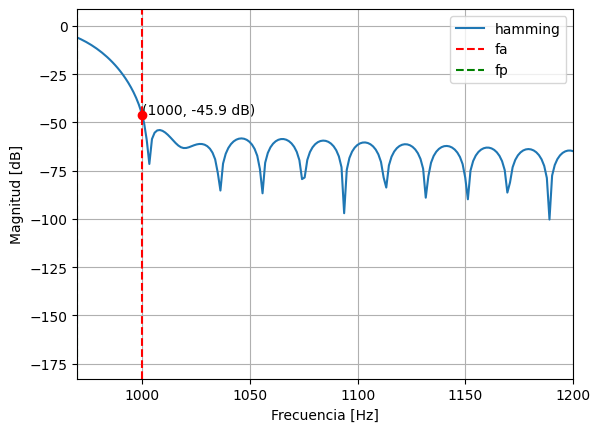

In [15]:
plt.figure()
fs_ds = 2000
fa  = fs_ds / 2

h = signal.firwin(
    numtaps,
    cutoff=fp,
    window=win,
    fs=fs
)


w, H = signal.freqz(h, worN=4096, fs=fs)

H_db = 20*np.log10(np.abs(H) + 1e-12)

plt.plot(w, H_db, label=f"{win}")

y_fa = np.interp(fa, w, H_db)
plt.text(fa, y_fa, f"({fa:.0f}, {y_fa:.1f} dB)")

plt.axvline(fa, linestyle='--', color='red', label='fa')
plt.axvline(fp, linestyle='--', color='green', label='fp')

plt.scatter(fa, y_fa, color='red', zorder=5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.xlim(fp, 1.2*fa)
plt.grid()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
fp = 970
fa = 1000

windows = ['boxcar', 'bartlett', 'hann', 'hamming', 'blackman']

def cumple_especificacion(numtaps, win):
    h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)
    w, H = signal.freqz(h, worN=4096, fs=fs)
    H_db = 20*np.log10(np.abs(H) + 1e-12)
    
    # --- banda de rechazo completa ---
    idx = w >= fa
    H_stop = H_db[idx]
    
    peor_caso = np.max(H_stop)  # peor punto (el más alto en dB)
    
    return peor_caso <= -50, peor_caso

resultados = {}

for win in windows:
    print(f"\nProbando ventana: {win}")
    
    numtaps = 51  # mejor empezar impar
    encontrado = False
    
    while numtaps < 5000:
        ok, peor_caso = cumple_especificacion(numtaps, win)
        
        if ok:
            print(f"✔ Cumple con {numtaps} taps (peor caso ≥1000Hz = {peor_caso:.2f} dB)")
            resultados[win] = numtaps
            encontrado = True
            break
        
        numtaps += 2  # mantener impar
    
    if not encontrado:
        print("❌ No cumple en el rango probado")

print("\nResumen:")
for win, taps in resultados.items():
    print(f"{win}: {taps} taps")


Probando ventana: boxcar
❌ No cumple en el rango probado

Probando ventana: bartlett
❌ No cumple en el rango probado

Probando ventana: hann
✔ Cumple con 761 taps (peor caso ≥1000Hz = -50.10 dB)

Probando ventana: hamming
✔ Cumple con 527 taps (peor caso ≥1000Hz = -50.22 dB)

Probando ventana: blackman
✔ Cumple con 741 taps (peor caso ≥1000Hz = -50.21 dB)

Resumen:
hann: 761 taps
hamming: 527 taps
blackman: 741 taps


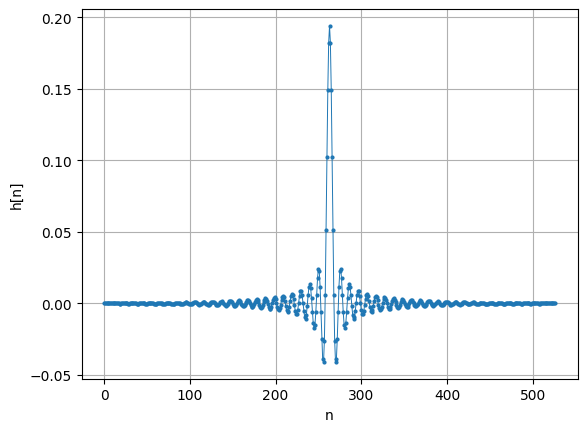

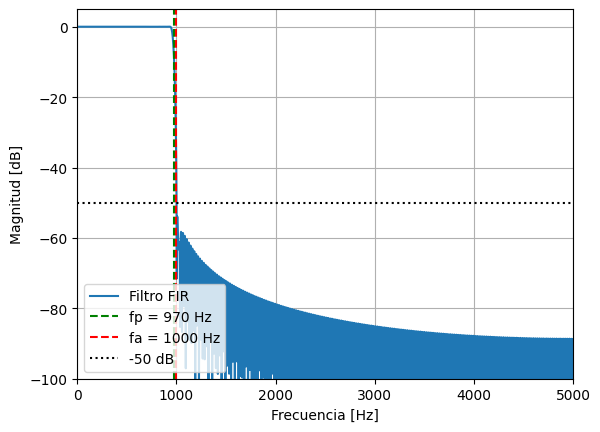

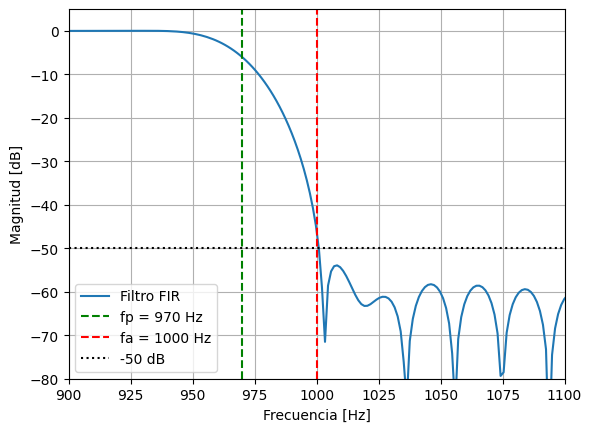

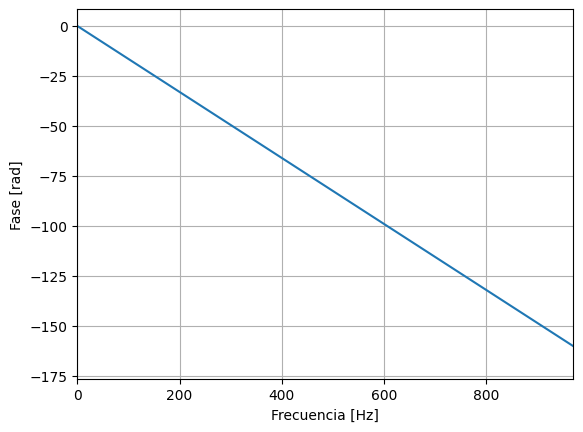

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- parámetros ---
fs = 10000
fp = 970
fa = 1000
numtaps = 527
win = 'hamming'

# --- diseño del filtro ---
h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)

# --- respuesta en frecuencia ---
w, H = signal.freqz(h, worN=4096, fs=fs)
H_db = 20*np.log10(np.abs(H) + 1e-12)
H_phase = np.unwrap(np.angle(H))

# --- peor caso en banda de rechazo ---
idx_stop = w >= fa
H_stop = H_db[idx_stop]
w_stop = w[idx_stop]

peor_valor = np.max(H_stop)
peor_freq = w_stop[np.argmax(H_stop)]

# =========================
# 1) RESPUESTA IMPULSIVA
# =========================
plt.figure()
plt.plot(h, marker='o', markersize=2, linewidth=0.7)
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid()

# =========================
# 2) MAGNITUD COMPLETA
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 3) ZOOM TRANSICIÓN
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(900, 1100)
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 4) FASE
# =========================
plt.figure()
plt.plot(w, H_phase)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(0, fp)
plt.grid()

plt.show()

Señal de entrada de prueba

In [31]:
fs = 10000
f = 600
t = np.arange(0, 10, 1/fs)
x = signal.square(2*np.pi*600*t)

(0.0, 0.06)

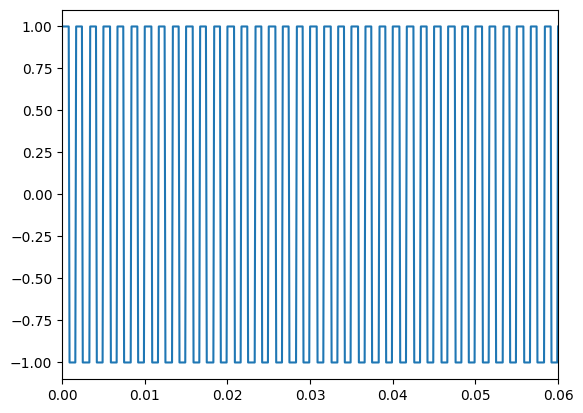

In [30]:
plt.plot(t, x)
plt.xlim(0, 600/fs)

Escriba su función de procesamiento FIR acá

In [39]:
import numpy as np
import time

def fir_filter(x, h):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    L = len(x)
    
    y = np.zeros(L)
    
    #Debemos realizar la convolución de h y x
    for n in range(L):
        for k in range(N):
            if n-k>=0:
                y[n] += h[k] * x[n-k]

    return y

In [ ]:
# --- filtrado ---
y = fir_filter(x, h)

#--- down-sampling ---
N_ds = 5

y_ds = y[::N_ds]
t_ds = t[::N_ds]

In [75]:
n_runs = 5
tiempos = []

for _ in range(n_runs):
    start = time.perf_counter()
    y = fir_filter(x, h)
    end = time.perf_counter()
    
    tiempos.append(end - start)

t_total = np.mean(tiempos)
t_por_muestra = t_total / len(x)

print(f"Tiempo total promedio: {t_total:.6f} s")
print(f"Tiempo por muestra: {t_por_muestra*1e6:.3f} us")

for i, t in enumerate(tiempos):
    print(f"Corrida {i+1}: {t:.6f} s")

Tiempo total promedio: 18.480776 s
Tiempo por muestra: 184.808 us
Corrida 1: 19.135894 s
Corrida 2: 18.456400 s
Corrida 3: 18.152865 s
Corrida 4: 18.438790 s
Corrida 5: 18.219928 s


In [ ]:
print(tiempos)

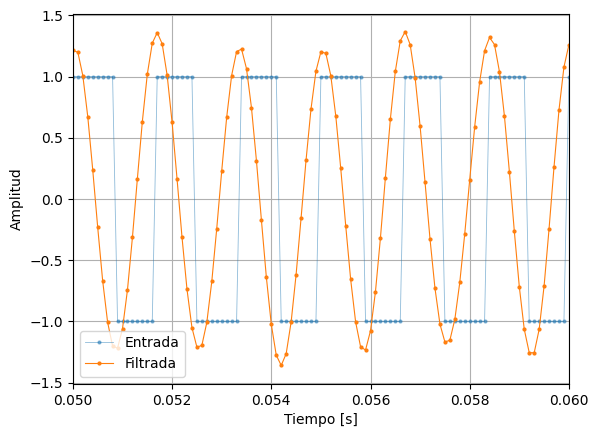

In [49]:
delay = (len(h) - 1) // 2

y_aligned = y[delay:]
t_aligned = t[delay:]

plt.figure()

plt.plot(t_aligned, x[delay:],
         marker='o', markersize=2,
         linewidth=0.6,
         alpha=0.5,
         label='Entrada')

plt.plot(t_aligned, y_aligned,
         marker='o', markersize=2,
         linewidth=0.8,
         label='Filtrada')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

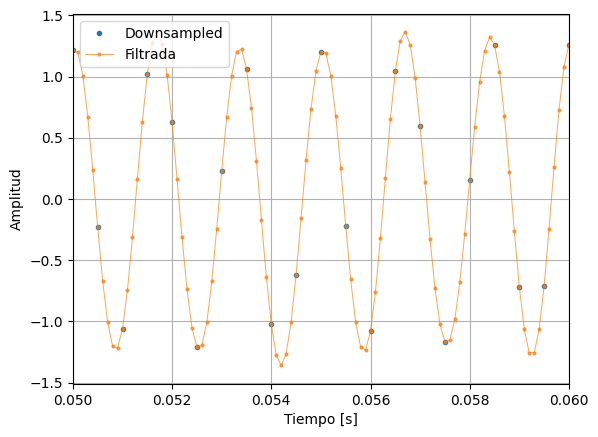

In [56]:
plt.figure()

plt.plot(t_ds, y_ds,
         marker='o', linestyle='none',
         markersize=3,
         label='Downsampled')

plt.plot(t, y,
         marker='o', markersize=2,
         linewidth=0.7,
         alpha=0.7,
         label='Filtrada')



plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

In [85]:
# --- ventana ---
win = np.hanning(len(x))
x_win = x * win

# --- FFT ---
X = np.fft.fft(x_win)
X = np.abs(X) / len(X)   # normalización

freq = np.fft.fftfreq(len(X), d=1/fs)

# solo frecuencias positivas
idx = freq >= 0
freq = freq[idx]
X = X[idx]

# --- ventana ---
win_y = np.hanning(len(y))
y_win = y * win_y

# --- FFT ---
Y = np.fft.fft(y_win)
Y = np.abs(Y) / len(Y)

freq_y = np.fft.fftfreq(len(Y), d=1/fs)

# solo frecuencias positivas
idx = freq_y >= 0
freq_y = freq_y[idx]
Y = Y[idx]


# --- ventana ---
win_y_ds = np.hanning(len(y_ds))
y_win_ds = y_ds * win_y_ds

# --- FFT ---
Y_ds = np.fft.fft(y_win_ds)
Y_ds = np.abs(Y_ds) / len(Y_ds)

freq_y_ds = np.fft.fftfreq(len(Y_ds), d=1/fs_ds)

# solo frecuencias positivas
idx = freq_y_ds >= 0
freq_y_ds = freq_y_ds[idx]
Y_ds = Y_ds[idx]


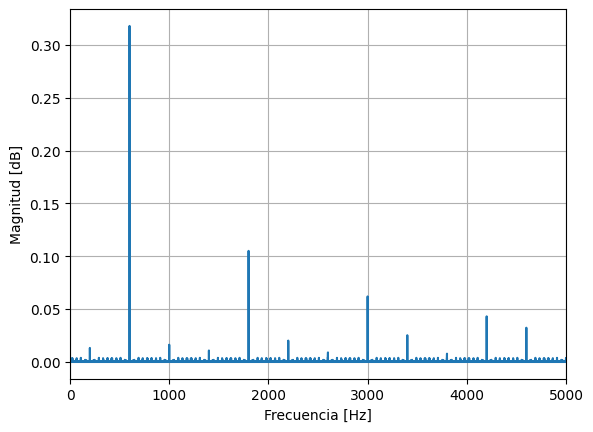

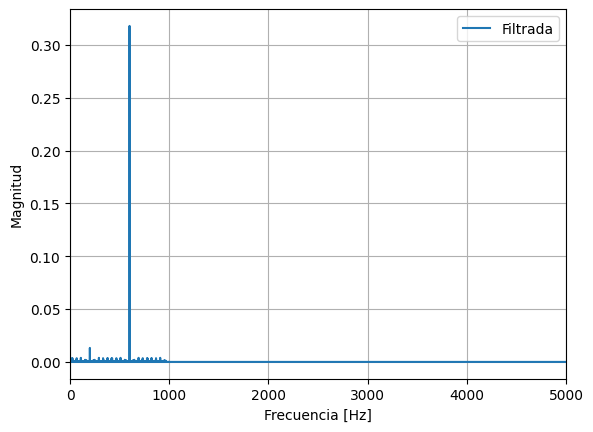

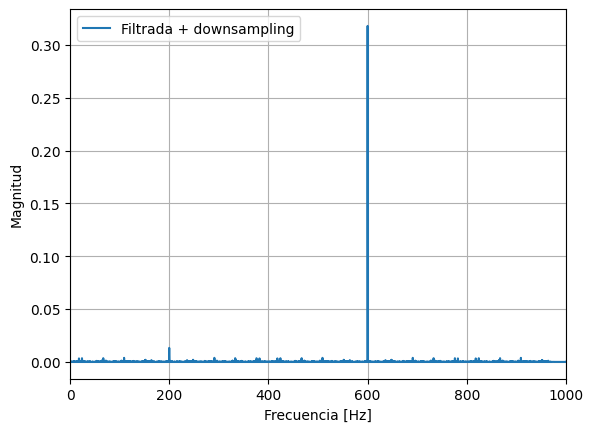

In [87]:
plt.figure()
plt.plot(freq, X)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, 5000)
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y, Y, label='Filtrada')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 5000)
plt.legend()
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y_ds, Y_ds, label='Filtrada + downsampling')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 1000)
plt.legend()
plt.grid()

plt.show()

## Ejercicio 3: FIR aplicando Overlap and Save

In [129]:
import numpy as np
import time

def overlap_save_fir(x, h, L=1024):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    K =             # tamaño FFT
    
    # Complete su código acá

    return y

SyntaxError: invalid syntax (3511122254.py, line 9)

In [ ]:
# Overlap-Save
y = overlap_save_fir(x, h, L=1024)

In [ ]:
y_ref = y

In [ ]:
import numpy as np
import time

# --- Datos de entrada (asumiendo que ya existen) ---
# h: tus 527 coeficientes
# x: tu señal de entrada
# y_ref: el resultado de ejercicio 1 (convolución lineal) para comparar

L = 1024
M = len(h)
N = 2048  # Potencia de 2 recomendada para h=527 y L=1024

# 1. Pre-cálculo: FFT del filtro (solo una vez)
H = np.fft.fft(h, n=N)

# Inicialización
salida_final = []
tiempos_bloque = []
pasado = np.zeros(M - 1) # M-1 ceros iniciales

# 2. Procesamiento por bloques
for i in range(0, len(x), L):
    start_time = time.perf_counter()
    
    # Tomamos el bloque actual de la señal
    bloque_actual = x[i : i + L]
    
    # Si el último bloque es más chico que L, lo rellenamos con ceros
    if len(bloque_actual) < L:
        bloque_actual = np.pad(bloque_actual, (0, L - len(bloque_actual)))
    
    # Armado del bloque de entrada N=2048: [pasado(526) + actual(1024) + ceros(498)]
    # Usamos np.concatenate o simplemente pasamos el tamaño a np.fft.fft
    entrada_fft = np.concatenate([pasado, bloque_actual])
    
    # Procesamiento espectral
    X = np.fft.fft(entrada_fft, n=N)
    Y = X * H
    y_bloque = np.fft.ifft(Y).real # Nos quedamos con la parte real
    
    # --- OVERLAP AND SAVE: Salvar desde el índice M-1 hasta (M-1 + L) ---
    # Esto extrae exactamente las 1024 muestras limpias
    bloque_limpio = y_bloque[M-1 : M-1+L]
    salida_final.extend(bloque_limpio)
    
    # Actualizamos el pasado para la siguiente iteración
    pasado = bloque_actual[-(M-1):]
    
    end_time = time.perf_counter()
    tiempos_bloque.append(end_time - start_time)

# 3. Mediciones y Comparación
salida_final = np.array(salida_final[:len(x)]) # Recortamos al largo original si es necesario
tiempo_total = sum(tiempos_bloque)
tiempo_por_muestra = tiempo_total / len(x)

print(f"Tiempo total: {tiempo_total:.4f} s")
print(f"Tiempo por muestra: {tiempo_por_muestra:.8f} s")

# Comparación con el ejercicio 1 (y_ref)
# Nota: y_ref debe ser recortado o comparado hasta len(x)
error = np.linalg.norm(salida_final - y_ref[:len(x)])
print(f"Error acumulado contra convolución: {error}")

Tiempo total: 0.0380 s
Tiempo por muestra: 0.00000038 s
Error acumulado contra convolución: 2.2228203505445087e-13


## Ejercicio 3: THD

### Comb

C:\Users\herra\AppData\Local\Temp\ipykernel_93928\3985673799.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


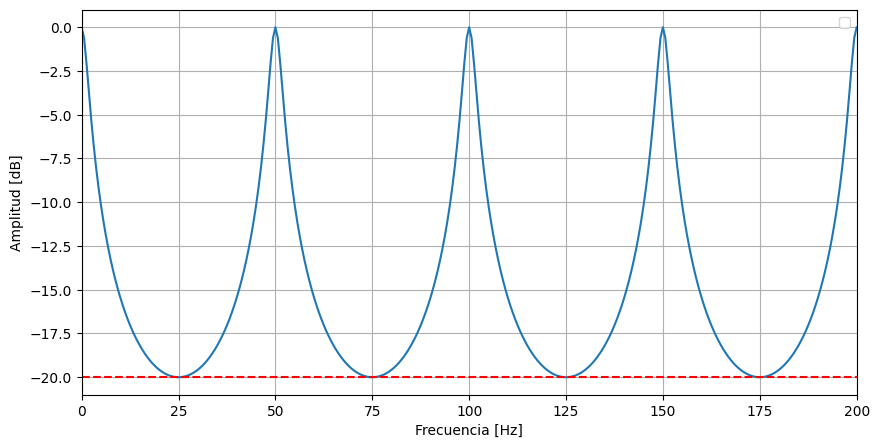

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz

# Parámetros del diseño según tu análisis
fs = 10000          # Frecuencia de muestreo (10 kHz)
f0 = 50             # Frecuencia fundamental (Hz)
k = int(fs / f0)    # Retraso (200 muestras)

# Coeficientes calculados
beta = 9/11
alpha = 2/11

# --- Definición del filtro ---
# La ecuación y[n] = alpha*x[n] + beta*y[n-k] se traduce a:
# y[n] - beta*y[n-k] = alpha*x[n]
# Coeficientes del numerador (b): alpha en la posición 0, luego k ceros
b = np.zeros(k + 1)
b[0] = alpha

# Coeficientes del denominador (a): 1 en la pos 0, -beta en la pos k
a = np.zeros(k + 1)
a[0] = 1.0
a[k] = -beta

# --- Análisis de Respuesta en Frecuencia ---
w, h = freqz(b, a, worN=8000, fs=fs)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(np.abs(h)))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.axhline(-20, color='red', linestyle='--')
plt.xlim(0, 200) # Zoom a las primeras componentes
plt.legend()
plt.show()

# --- Ejemplo de uso con una señal ---
# x = señal_de_entrada
# y1 = lfilter(b, a, x)

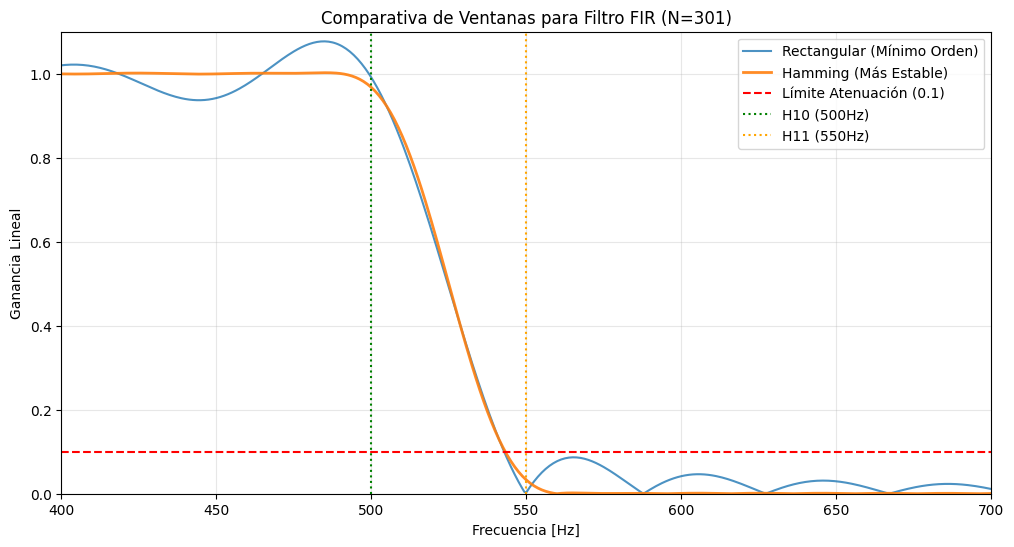

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
numtaps_rect = 251
numtaps_hamming = 501
fc = 525

# Diseño de ambos filtros
taps_rect = signal.firwin(numtaps_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(numtaps_hamming, fc, fs=fs, window='hamming')

# Respuestas en frecuencia
w, h_rect = signal.freqz(taps_rect, [1], worN=8000, fs=fs)
w, h_hamm = signal.freqz(taps_hamm, [1], worN=8000, fs=fs)

# Graficar
plt.figure(figsize=(12, 6))

plt.plot(w, np.abs(h_rect), label='Rectangular (Mínimo Orden)', alpha=0.8, linewidth=1.5)
plt.plot(w, np.abs(h_hamm), label='Hamming (Más Estable)', alpha=0.9, linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(500, color='green', linestyle=':', label='H10 (500Hz)')
plt.axvline(550, color='orange', linestyle=':', label='H11 (550Hz)')

plt.title(f'Comparativa de Ventanas para Filtro FIR (N={numtaps})')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(400, 700)  # Zoom en la zona crítica de transición
plt.ylim(0, 1.1)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [147]:
# Definimos los armónicos de interés (del 1 al 11)
armonicos = np.arange(50, 600, 50)

# Función para obtener la ganancia en frecuencias específicas
def obtener_ganancias(w, h, freqs):
    # Interpolamos la magnitud (np.abs(h)) en las frecuencias deseadas
    return np.interp(freqs, w, np.abs(h))

ganancias_rect = obtener_ganancias(w, h_rect, armonicos)
ganancias_hamm = obtener_ganancias(w, h_hamm, armonicos)

# Mostrar resultados
print(f"{'Frec [Hz]':<10} | {'Rect (N=201)':<15} | {'Hamming (N=01)':<15}")
print("-" * 45)
for i, f in enumerate(armonicos):
    print(f"{f:<10} | {ganancias_rect[i]:<15.4f} | {ganancias_hamm[i]:<15.4f}")

Frec [Hz]  | Rect (N=201)    | Hamming (N=01) 
---------------------------------------------
50         | 0.9772          | 1.0003         
100        | 0.9879          | 1.0007         
150        | 0.9959          | 1.0005         
200        | 0.9713          | 0.9999         
250        | 1.0013          | 1.0001         
300        | 0.9828          | 1.0009         
350        | 0.9733          | 1.0008         
400        | 1.0200          | 0.9995         
450        | 0.9420          | 0.9996         
500        | 0.9911          | 0.9675         
550        | 0.0030          | 0.0328         


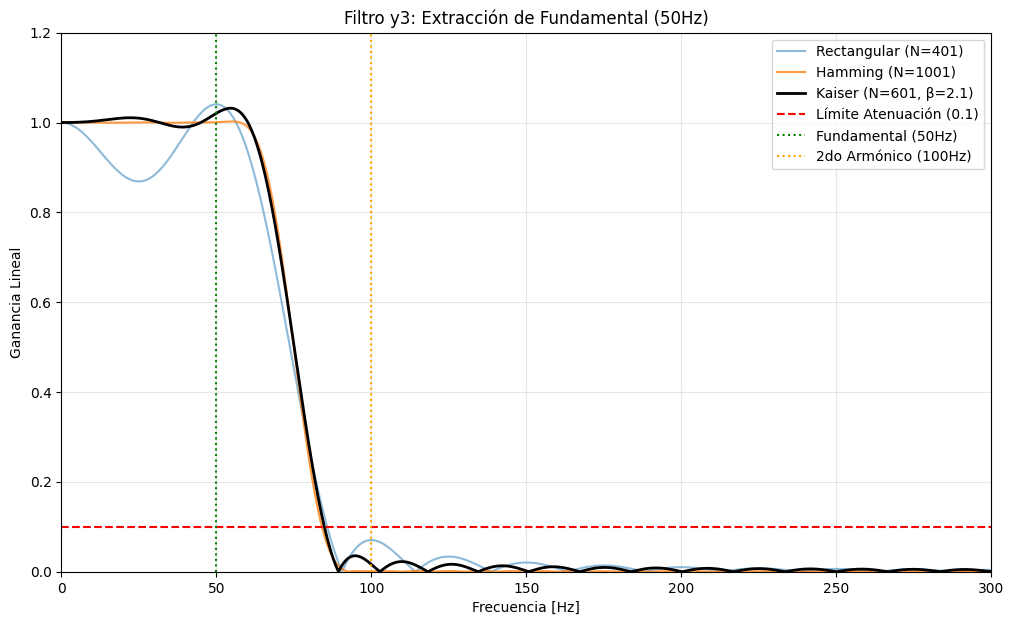

Armónico     | Frec [Hz]  | Rect       | Rect Comp.   | Hamming    | Kaiser    
-------------------------------------------------------------------------------------
H1          | 50         | 1.0407     | 1.0000       | 1.0008     | 1.0205    
H2          | 100        | 0.0704     | 0.0677       | 0.0008     | 0.0165    
H3          | 150        | 0.0205     | 0.0197       | 0.0000     | 0.0018    
H4          | 200        | 0.0102     | 0.0098       | 0.0000     | 0.0005    
H5          | 250        | 0.0062     | 0.0060       | 0.0000     | 0.0001    
H6          | 300        | 0.0042     | 0.0041       | 0.0000     | 0.0001    
H7          | 350        | 0.0031     | 0.0029       | 0.0000     | 0.0002    
H8          | 400        | 0.0023     | 0.0022       | 0.0000     | 0.0003    
H9          | 450        | 0.0018     | 0.0017       | 0.0000     | 0.0003    
H10         | 500        | 0.0015     | 0.0014       | 0.0000     | 0.0003    
H11         | 550        | 0.0012     | 0.00

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuración Inicial ---
fs = 10000
fc = 75  # Corte en el punto medio entre 50Hz (H1) y 100Hz (H2)
armonicos = np.arange(50, 601, 50)

# --- Órdenes Óptimos para recuperar la Fundamental ---
# Nota: Los órdenes suben porque la banda de transición es de solo 50Hz
n_rect = 401   
n_hamm = 1001  
n_kais = 501   
beta_k = 2.1  # Beta bajo para maximizar pendiente

# --- Diseño de Filtros ---
taps_rect = signal.firwin(n_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(n_hamm, fc, fs=fs, window='hamming')
taps_kais = signal.firwin(n_kais, fc, fs=fs, window=('kaiser', beta_k))

# --- Respuesta en Frecuencia ---
def get_response(taps):
    w, h = signal.freqz(taps, [1], worN=20000, fs=fs)
    return w, h

w_r, h_r = get_response(taps_rect)
w_h, h_h = get_response(taps_hamm)
w_k, h_k = get_response(taps_kais)

# --- Función para obtener ganancias ---
def check_gain(w, h, freqs):
    return np.interp(freqs, w, np.abs(h))

g_rect = check_gain(w_r, h_r, armonicos)
g_hamm = check_gain(w_h, h_h, armonicos)
g_kais = check_gain(w_k, h_k, armonicos)

# --- COMPENSACIÓN RECTANGULAR ---
# Calculamos el factor para que la ganancia en 50Hz sea exactamente 1.0
factor_comp = 1.0 / g_rect[0]
g_rect_comp = g_rect * factor_comp

# --- 1. Gráfica Comparativa ---
plt.figure(figsize=(12, 7))

plt.plot(w_r, np.abs(h_r), label=f'Rectangular (N={n_rect})', alpha=0.5)
plt.plot(w_h, np.abs(h_h), label=f'Hamming (N={n_hamm})', alpha=0.8)
plt.plot(w_k, np.abs(h_k), label=f'Kaiser (N={n_kais}, β={beta_k})', color='black', linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(50, color='green', linestyle=':', label='Fundamental (50Hz)')
plt.axvline(100, color='orange', linestyle=':', label='2do Armónico (100Hz)')

plt.title('Filtro y3: Extracción de Fundamental (50Hz)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(0, 300)  # Zoom en la zona de la fundamental
plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. Tabla de Resultados ---
print(f"{'Armónico':<12} | {'Frec [Hz]':<10} | {'Rect':<10} | {'Rect Comp.':<12} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 85)
for i, f in enumerate(armonicos):
    h_num = f // 50
    print(f"H{h_num:<10} | {f:<10} | {g_rect[i]:<10.4f} | {g_rect_comp[i]:<12.4f} | {g_hamm[i]:<10.4f} | {g_kais[i]:<10.4f}")

# --- 3. Reporte de Error en la Fundamental (H1) ---
err_r = np.abs(1 - g_rect[0]) * 100
err_rc = np.abs(1 - g_rect_comp[0]) * 100
err_h = np.abs(1 - g_hamm[0]) * 100
err_k = np.abs(1 - g_kais[0]) * 100

print(f"\n{'Métrica':<20} | {'Rect':<10} | {'Rect Comp':<10} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 70)
print(f"{'Error en 50Hz [%]':<20} | {err_r:<10.4f} | {err_rc:<10.4f} | {err_h:<10.4f} | {err_k:<10.4f}")
print(f"{'Ganancia en 100Hz':<20} | {g_rect[1]:<10.4f} | {g_rect_comp[1]:<10.4f} | {g_hamm[1]:<10.4f} | {g_kais[1]:<10.4f}")
print(f"{'CUMPLE ATEN. H2':<20} | {str(g_rect_comp[1]<0.1):<10} | {str(g_rect_comp[1]<0.1):<10} | {str(g_hamm[1]<0.1):<10} | {str(g_kais[1]<0.1):<10}")

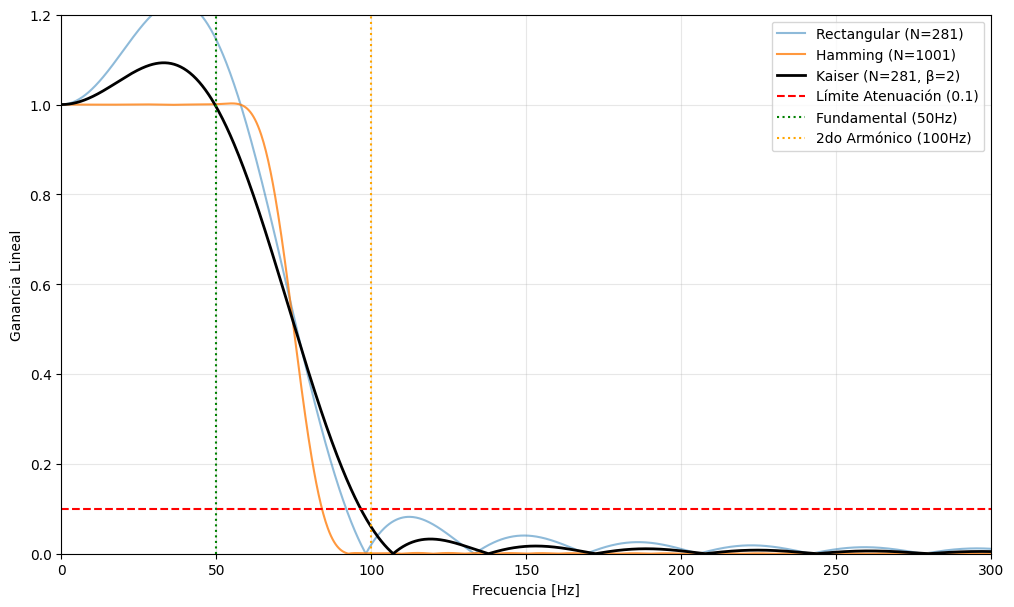

Armónico     | Frec [Hz]  | Rect       | Rect Comp.   | Hamming    | Kaiser    
-------------------------------------------------------------------------------------
H1          | 50         | 1.1443     | 1.0000       | 1.0008     | 0.9945    
H2          | 100        | 0.0204     | 0.0179       | 0.0008     | 0.0591    
H3          | 150        | 0.0404     | 0.0353       | 0.0000     | 0.0164    
H4          | 200        | 0.0105     | 0.0092       | 0.0000     | 0.0063    
H5          | 250        | 0.0101     | 0.0088       | 0.0000     | 0.0036    
H6          | 300        | 0.0110     | 0.0096       | 0.0000     | 0.0048    
H7          | 350        | 0.0002     | 0.0001       | 0.0000     | 0.0004    
H8          | 400        | 0.0073     | 0.0064       | 0.0000     | 0.0030    
H9          | 450        | 0.0044     | 0.0038       | 0.0000     | 0.0020    
H10         | 500        | 0.0030     | 0.0026       | 0.0000     | 0.0011    
H11         | 550        | 0.0052     | 0.00

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuración Inicial ---
fs = 10000
fc = 75  # Corte en el punto medio entre 50Hz (H1) y 100Hz (H2)
armonicos = np.arange(50, 601, 50)

# --- Órdenes Óptimos para recuperar la Fundamental ---
# Nota: Los órdenes suben porque la banda de transición es de solo 50Hz
n_rect = 281   
n_hamm = 1001  
n_kais = 281   
beta_k = 2  # Beta bajo para maximizar pendiente

# --- Diseño de Filtros ---
taps_rect = signal.firwin(n_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(n_hamm, fc, fs=fs, window='hamming')
taps_kais = signal.firwin(n_kais, fc, fs=fs, window=('kaiser', beta_k))

# --- Respuesta en Frecuencia ---
def get_response(taps):
    w, h = signal.freqz(taps, [1], worN=20000, fs=fs)
    return w, h

w_r, h_r = get_response(taps_rect)
w_h, h_h = get_response(taps_hamm)
w_k, h_k = get_response(taps_kais)

# --- Función para obtener ganancias ---
def check_gain(w, h, freqs):
    return np.interp(freqs, w, np.abs(h))

g_rect = check_gain(w_r, h_r, armonicos)
g_hamm = check_gain(w_h, h_h, armonicos)
g_kais = check_gain(w_k, h_k, armonicos)

# --- COMPENSACIÓN RECTANGULAR ---
# Calculamos el factor para que la ganancia en 50Hz sea exactamente 1.0
factor_comp = 1.0 / g_rect[0]
g_rect_comp = g_rect * factor_comp

# --- 1. Gráfica Comparativa ---
plt.figure(figsize=(12, 7))

plt.plot(w_r, np.abs(h_r), label=f'Rectangular (N={n_rect})', alpha=0.5)
plt.plot(w_h, np.abs(h_h), label=f'Hamming (N={n_hamm})', alpha=0.8)
plt.plot(w_k, np.abs(h_k), label=f'Kaiser (N={n_kais}, β={beta_k})', color='black', linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(50, color='green', linestyle=':', label='Fundamental (50Hz)')
plt.axvline(100, color='orange', linestyle=':', label='2do Armónico (100Hz)')


plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(0, 300)  # Zoom en la zona de la fundamental
plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. Tabla de Resultados ---
print(f"{'Armónico':<12} | {'Frec [Hz]':<10} | {'Rect':<10} | {'Rect Comp.':<12} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 85)
for i, f in enumerate(armonicos):
    h_num = f // 50
    print(f"H{h_num:<10} | {f:<10} | {g_rect[i]:<10.4f} | {g_rect_comp[i]:<12.4f} | {g_hamm[i]:<10.4f} | {g_kais[i]:<10.4f}")

# --- 3. Reporte de Error en la Fundamental (H1) ---
err_r = np.abs(1 - g_rect[0]) * 100
err_rc = np.abs(1 - g_rect_comp[0]) * 100
err_h = np.abs(1 - g_hamm[0]) * 100
err_k = np.abs(1 - g_kais[0]) * 100

print(f"\n{'Métrica':<20} | {'Rect':<10} | {'Rect Comp':<10} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 70)
print(f"{'Error en 50Hz [%]':<20} | {err_r:<10.4f} | {err_rc:<10.4f} | {err_h:<10.4f} | {err_k:<10.4f}")
print(f"{'Ganancia en 100Hz':<20} | {g_rect[1]:<10.4f} | {g_rect_comp[1]:<10.4f} | {g_hamm[1]:<10.4f} | {g_kais[1]:<10.4f}")
print(f"{'CUMPLE ATEN. H2':<20} | {str(g_rect_comp[1]<0.1):<10} | {str(g_rect_comp[1]<0.1):<10} | {str(g_hamm[1]<0.1):<10} | {str(g_kais[1]<0.1):<10}")

[1.0, 0.5, 0.3333333333333333, 0.2, 0.125, 0.07692307692307693, 0.047619047619047616, 0.029411764705882353, 0.01818181818181818, 0.011235955056179775, 0.006944444444444444, 0.004291845493562232, 0.002652519893899204, 0.001639344262295082, 0.0010131712259371835, 0.0006261740763932373, 0.0003869969040247678, 0.00023917723032767282, 0.00014781966001478197, 9.13575735428467e-05, 5.646208570944611e-05, 3.489548801339987e-05, 2.1566597653554176e-05, 1.3328890369876708e-05, 8.237707281309466e-06, 5.0911830891262516e-06, 3.1465241920512505e-06, 1.944658897106153e-06, 1.2018652949377434e-06, 7.427936021701458e-07, 4.5907169276718775e-07, 2.837219094030548e-07, 1.7534978336411013e-07, 1.0837212603895002e-07, 6.697765732515884e-08, 4.1394468713791485e-08, 2.558318861136729e-08, 1.5811280102424208e-08, 9.77190850894308e-09, 6.039371593481129e-09, 3.73253691546195e-09, 2.3068346780191785e-09, 1.4257022374427722e-09, 8.811324405764062e-10, 5.44569796866366e-10, 3.365626437100402e-10, 2.0800715315632

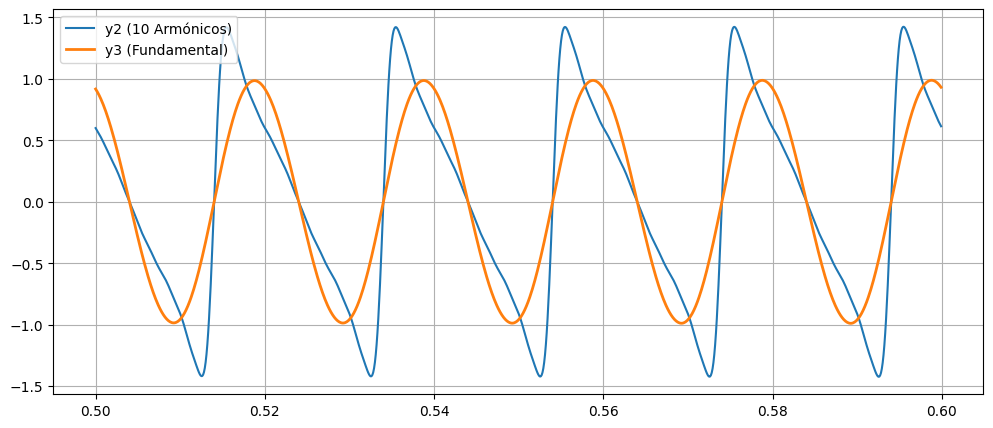

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. Parámetros Globales ---
fs = 10000
duration = 1.0  # 1 segundo
t = np.arange(0, duration, 1/fs)
f0 = 50

# --- 2. Generación de Señal Sintética (Fibonacci) ---
def fibonacci_amplitudes(n_harmonics):
    fib = [1, 1]
    for i in range(2, n_harmonics + 2):
        fib.append(fib[-1] + fib[-2])
    # Ak = 1 / f_{k+1}
    return [1/fib[k] for k in range(1, n_harmonics + 1)]

# Generamos armónicos hasta Nyquist (fs/2 = 5000Hz -> 100 armónicos)
K = 100 
A = fibonacci_amplitudes(K)
x = np.zeros_like(t)

for k in range(1, K + 1):
    x += A[k-1] * np.sin(2 * np.pi * k * f0 * t)

# --- 3. Filtro Comb (y1) ---
# y1[n] = alpha*x[n] + beta*y1[n-k]
alpha = 2/11
beta = 9/11
k_delay = 200

# Implementación recursiva del Comb
# b = [alpha], a = [1, 0, 0, ..., -beta]
b_comb = [alpha]
a_comb = np.zeros(k_delay + 1)
a_comb[0] = 1
a_comb[k_delay] = -beta
y1 = signal.lfilter(b_comb, a_comb, x)

# --- 4. Filtros FIR Kaiser (y2 e y3) ---
# y2: Recupera 10 armónicos
n2 = 281
beta2 = 1.8
fc2 = 530
taps_y2 = signal.firwin(n2, fc2, fs=fs, window=('kaiser', beta2))
y2 = signal.lfilter(taps_y2, [1.0], y1)

# y3: Recupera fundamental
n3 = 281
beta3 = 2.0
fc3 = 75
taps_y3 = signal.firwin(n3, fc3, fs=fs, window=('kaiser', beta3))
y3 = signal.lfilter(taps_y3, [1.0], y1)

# --- 5. Cálculo de THD ---
# Para evitar el transitorio inicial de los filtros, descartamos el primer tramo
# El retardo máximo es la suma de los FIR (aprox 300 muestras)
offset = 5000 
y2_steady = y2[offset:]
y3_steady = y3[offset:]

# Valores RMS
Vt = np.sqrt(np.mean(y2_steady**2))
V0 = np.sqrt(np.mean(y3_steady**2))

# THD = sqrt(Vt^2 - V0^2) / V0
thd_calculado = (np.sqrt(Vt**2 - V0**2) / V0) * 100

# --- 6. Validación Teórica ---
# THD_teorico usando los primeros 10 armónicos (A1 a A10)
sum_sq_harmonics = np.sum(np.array(A[1:10])**2)
thd_teorico = (np.sqrt(sum_sq_harmonics) / A[0]) * 100

print(A)
print(f"--- Resultados del Analizador ---")
print(f"V_total (10 armónicos): {Vt:.4f}")
print(f"V_fundamental (V0):     {V0:.4f}")
print(f"THD calculado:          {thd_calculado:.2f}%")
print(f"THD teórico (H2-H10):   {thd_teorico:.2f}%")

# --- 7. Visualización ---
plt.figure(figsize=(12, 5))
plt.plot(t[offset:offset+1000], y2[offset:offset+1000], label='y2 (10 Armónicos)')
plt.plot(t[offset:offset+1000], y3[offset:offset+1000], label='y3 (Fundamental)', linewidth=2)
plt.legend()
plt.grid(True)
plt.show()